In [144]:
!pip install odfpy

In [145]:
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, StandardScaler, PolynomialFeatures
from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score
import xgboost as xgb


In [146]:
df = pd.read_csv('annonimized.csv')

In [147]:
df.rename(columns={
    "concat('it001',`assignment_id`)": 'assignment_id',
    "concat('it001',`problem_id`)": 'problem_id',
    "concat('it001', username)": 'username',
    "concat('it001',`language_id`)": 'language_id'
}, inplace=True)

In [148]:
distinct_usernames = df['username'].nunique()

print(f"Number of distinct usernames: {distinct_usernames}")

Number of distinct usernames: 1489


In [149]:
assignment_df = df.groupby('assignment_id')['problem_id'].nunique().reset_index()
assignment_df.rename(columns={'problem_id': 'num_problems'}, inplace=True)
print(assignment_df)

                                assignment_id  num_problems
0    0110c1b3d0b4a08b95e05a48be6924e043e68ffe            10
1    013a41bc4aab7ce974228df5a2b5d5e6e0da64e8            16
2    0271545dae97fb752a588e6b97d55e4009565b35            25
3    02b71138af0269da597fee7614137d3a0ad75326             2
4    03190ab3ec4705c66358cd102fdb719bc8ab13bb             5
..                                        ...           ...
198  fdb39b60bce4591bdac572cc1f03d4f3417df16e             9
199  fe1bf6b299645a8e2502b0a43fa57d650d1b1b41             5
200  feac75b57862fb1653d3835bea439742ea93c8c8             4
201  febe93930de7a9a910e8a55177a7bce45de7329b            24
202  ff1bb207f10b6d6999751f65f3abf047f2b9242c            18

[203 rows x 2 columns]


In [150]:
solved_df = df[df['pre_score'] == 10000]
problem_df = (
    solved_df.groupby('problem_id')['username']
    .nunique()  # Count unique usernames
    .reset_index(name='solver_count')  # Reset index and rename the count column
)

In [151]:
problem_df.head()

,problem_id,solver_count
0,008f8e9b0f4fac6b5f188f0dc8d118a8b19aabee,890
1,013e2f57867e3ab62d2043beecedade7ea6cf545,8
2,017ff00dd3fe1e6f8297b5061215343742259f6a,451
3,027fd74619cb74676a464759ddfeb06457d80aa4,5
4,028df0dceb107528f66ee892dae5ded64b21d470,13


In [152]:
df.head()

,assignment_id,problem_id,username,is_final,status,pre_score,coefficient,language_id,created_at,updated_at,judgement
0,90ce27571176d87961b565d5ef4b3de33ede04ac,789454427dd4097a14749e3dde63346b7a8d3811,ed9eaeb6a707f50154024b24d7efcb874a9795dd,0,SCORE,0,100,it0012,10-09 08:02:04,10-09 08:06:58,"{""times"":[0,0,0,0,0,0,0,0,0,0],""mems"":[0,0,0,0..."
1,90ce27571176d87961b565d5ef4b3de33ede04ac,789454427dd4097a14749e3dde63346b7a8d3811,ed9eaeb6a707f50154024b24d7efcb874a9795dd,0,SCORE,0,100,it0012,10-09 08:04:41,10-09 08:04:51,"{""times"":[0,0,0,0,0,0,0,0,0,0],""mems"":[0,0,0,0..."
2,90ce27571176d87961b565d5ef4b3de33ede04ac,789454427dd4097a14749e3dde63346b7a8d3811,ed9eaeb6a707f50154024b24d7efcb874a9795dd,1,SCORE,10000,100,it0012,10-09 08:06:49,10-09 08:06:58,"{""times"":[0,0,0,0,0,0,0,0,0,0],""mems"":[0,0,0,0..."
3,90ce27571176d87961b565d5ef4b3de33ede04ac,bf96fbdc5f499538c3e2bfbec5779c8a14b0a9ff,ed9eaeb6a707f50154024b24d7efcb874a9795dd,1,SCORE,10000,100,it0012,10-09 08:47:52,10-09 08:48:01,"{""times"":[0,0,0,0,0,0,0,0,0,0],""mems"":[0,0,0,0..."
4,90ce27571176d87961b565d5ef4b3de33ede04ac,7a6e5ca470ff47c3b5048f240c4738de71010c78,ed9eaeb6a707f50154024b24d7efcb874a9795dd,1,SCORE,10000,100,it0012,10-09 09:19:35,10-09 09:19:45,"{""times"":[0,0,0,0,0,0,0,0,0,0],""mems"":[0,0,0,0..."


In [153]:
df_tl = pd.read_excel('tbtl-public.ods', engine="odf", header=None)
df_qt = pd.read_csv('qt-public.csv', header=None)
df_ck = pd.read_csv('ck-public.csv', header=None)
df_th = pd.read_csv('th-public.csv', header=None)

In [154]:
df_tl.columns = ['username', 'TBTL']
df_qt.columns = ['username', 'QT']
df_ck.columns = ['username', 'CK']
df_th.columns = ['username', 'TH']

# EDA

In [155]:
df.dtypes

,0
assignment_id,object
problem_id,object
username,object
is_final,int64
status,object
pre_score,int64
coefficient,int64
language_id,object
created_at,object
updated_at,object


In [156]:
df_tl.dtypes

,0
username,object
TBTL,object


In [157]:
df_qt.dtypes

,0
username,object
QT,object


In [158]:
df_ck.dtypes

,0
username,object
CK,object


In [159]:
df_th.dtypes

,0
username,object
TH,object


In [160]:
# prompt: check for missing value in df

# Check for missing values in each DataFrame
print("Missing values in df:")
print(df.isnull().sum())

print("\nMissing values in df_tl:")
print(df_tl.isnull().sum())

print("\nMissing values in df_qt:")
print(df_qt.isnull().sum())

print("\nMissing values in df_ck:")
print(df_ck.isnull().sum())

print("\nMissing values in df_th:")
print(df_th.isnull().sum())

Missing values in df:
assignment_id    0
problem_id       0
username         0
is_final         0
status           0
pre_score        0
coefficient      0
language_id      0
created_at       0
updated_at       0
judgement        0
dtype: int64

Missing values in df_tl:
username    0
TBTL        0
dtype: int64

Missing values in df_qt:
username    0
QT          6
dtype: int64

Missing values in df_ck:
username    0
CK          6
dtype: int64

Missing values in df_th:
username    0
TH          6
dtype: int64


In [161]:
# prompt: remove all sample that have nan value

# Remove rows with NaN values in 'TBTL' column of df_tl
df_tl = df_tl.dropna(subset=['TBTL'])

# Remove rows with NaN values in 'QT' column of df_qt
df_qt = df_qt.dropna(subset=['QT'])

# Remove rows with NaN values in 'CK' column of df_ck
df_ck = df_ck.dropna(subset=['CK'])

# Remove rows with NaN values in 'TH' column of df_th
df_th = df_th.dropna(subset=['TH'])

In [162]:
# Convert columns to numeric, coercing errors to NaN
df_tl['TBTL'] = pd.to_numeric(df_tl['TBTL'], errors='coerce')
df_qt['QT'] = pd.to_numeric(df_qt['QT'], errors='coerce')
df_ck['CK'] = pd.to_numeric(df_ck['CK'], errors='coerce')
df_th['TH'] = pd.to_numeric(df_th['TH'], errors='coerce')

<ipython-input-162-a7c15209839e>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_qt['QT'] = pd.to_numeric(df_qt['QT'], errors='coerce')
<ipython-input-162-a7c15209839e>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ck['CK'] = pd.to_numeric(df_ck['CK'], errors='coerce')
<ipython-input-162-a7c15209839e>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://p

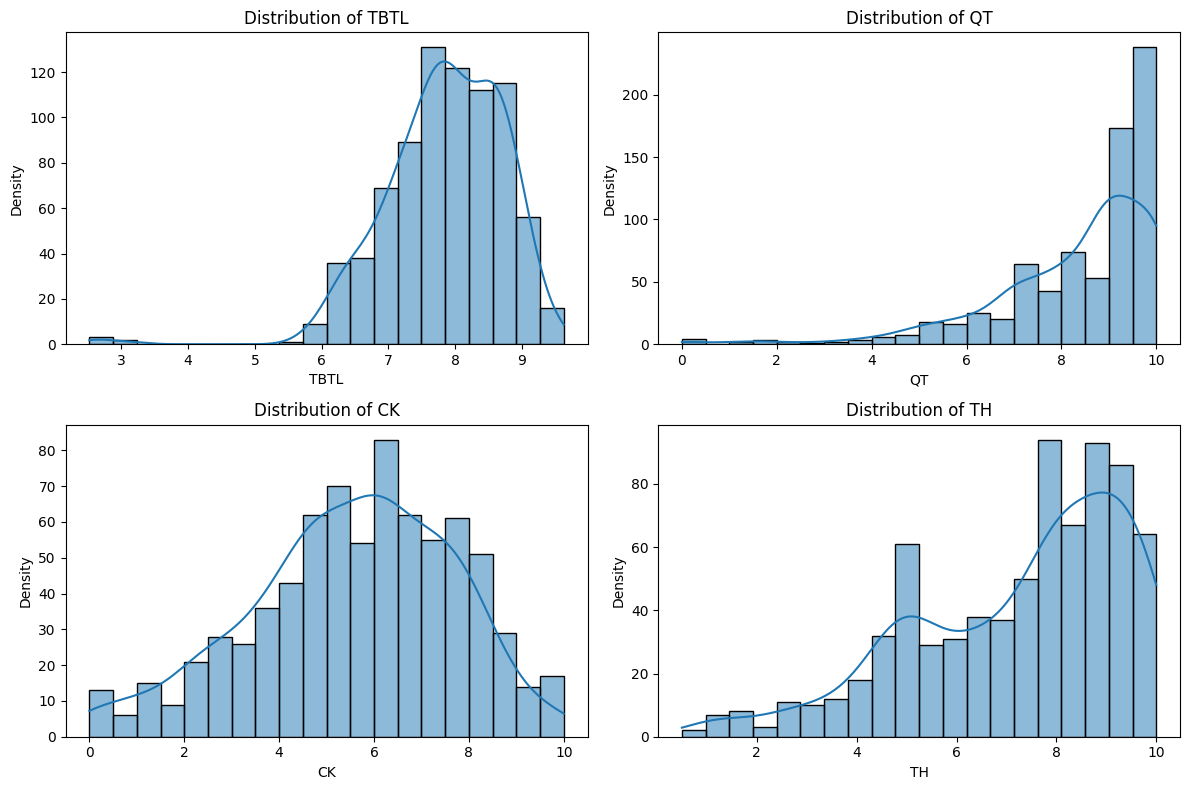

<Figure size 640x480 with 0 Axes>

In [163]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming df_tl, df_qt, df_ck, df_th are already defined and loaded as DataFrames

plt.figure(figsize=(12, 8))

# Plot TBTL distribution
plt.subplot(2, 2, 1)
sns.histplot(df_tl['TBTL'], kde=True, bins=20, edgecolor='black')
plt.title('Distribution of TBTL')
plt.xlabel('TBTL')
plt.ylabel('Density')

# Plot QT distribution
plt.subplot(2, 2, 2)
sns.histplot(df_qt['QT'], kde=True, bins=20, edgecolor='black')
plt.title('Distribution of QT')
plt.xlabel('QT')
plt.ylabel('Density')

# Plot CK distribution
plt.subplot(2, 2, 3)
sns.histplot(df_ck['CK'], kde=True, bins=20, edgecolor='black')
plt.title('Distribution of CK')
plt.xlabel('CK')
plt.ylabel('Density')

# Plot TH distribution
plt.subplot(2, 2, 4)
sns.histplot(df_th['TH'], kde=True, bins=20, edgecolor='black')
plt.title('Distribution of TH')
plt.xlabel('TH')
plt.ylabel('Density')

plt.tight_layout()
plt.show()

plt.tight_layout()
plt.show()

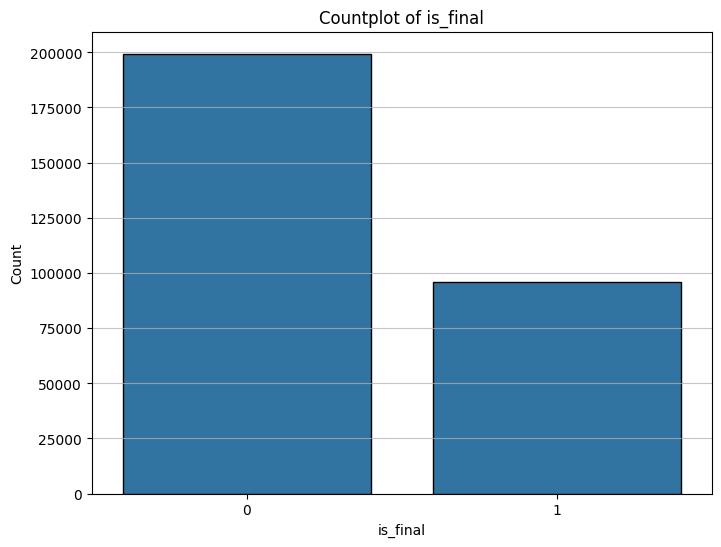

In [164]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='is_final', edgecolor='black')
plt.title('Countplot of is_final')
plt.xlabel('is_final')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.75)
plt.show()

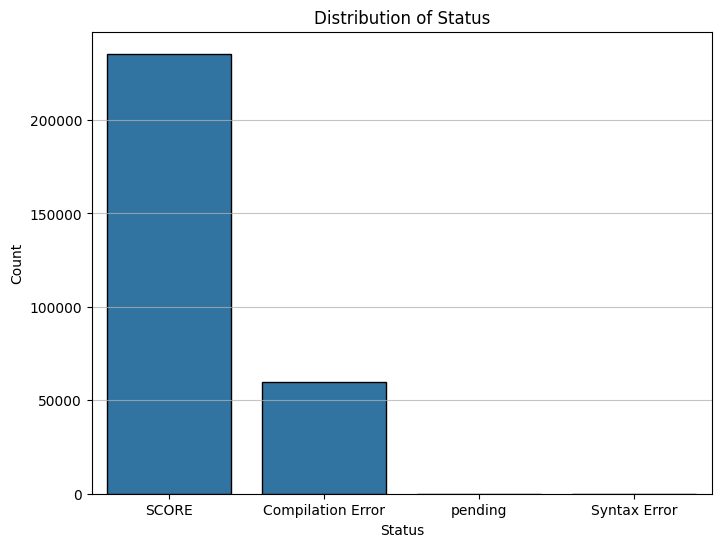

In [165]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='status', edgecolor='black')
plt.title('Distribution of Status')
plt.xlabel('Status')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.75)
plt.show()

Text(0, 0.5, 'Density')

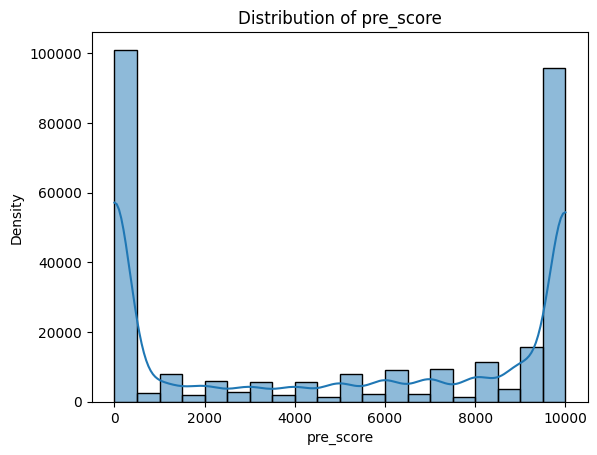

In [166]:
sns.histplot(df['pre_score'], kde=True, bins=20, edgecolor='black')
plt.title('Distribution of pre_score')
plt.xlabel('pre_score')
plt.ylabel('Density')

Text(0, 0.5, 'Density')

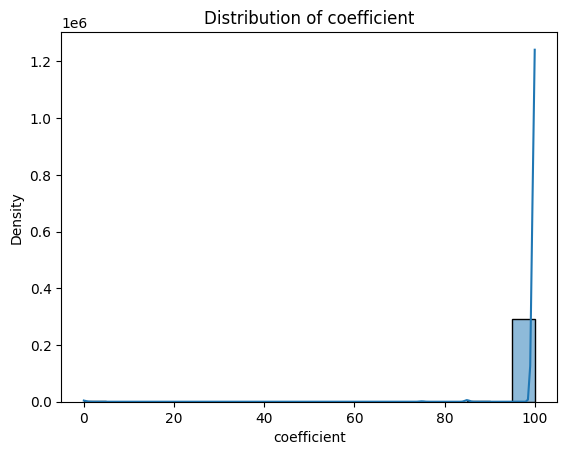

In [167]:
sns.histplot(df['coefficient'], kde=True, bins=20, edgecolor='black')
plt.title('Distribution of coefficient')
plt.xlabel('coefficient')
plt.ylabel('Density')

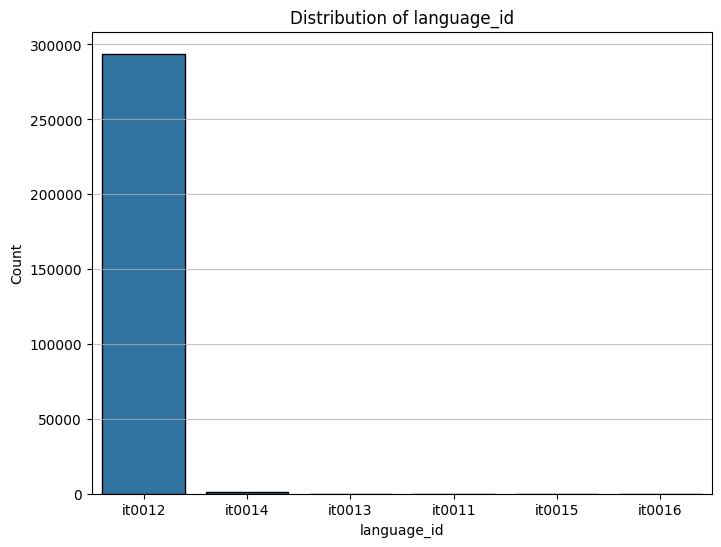

In [168]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='language_id', edgecolor='black')
plt.title('Distribution of language_id')
plt.xlabel('language_id')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.75)
plt.show()

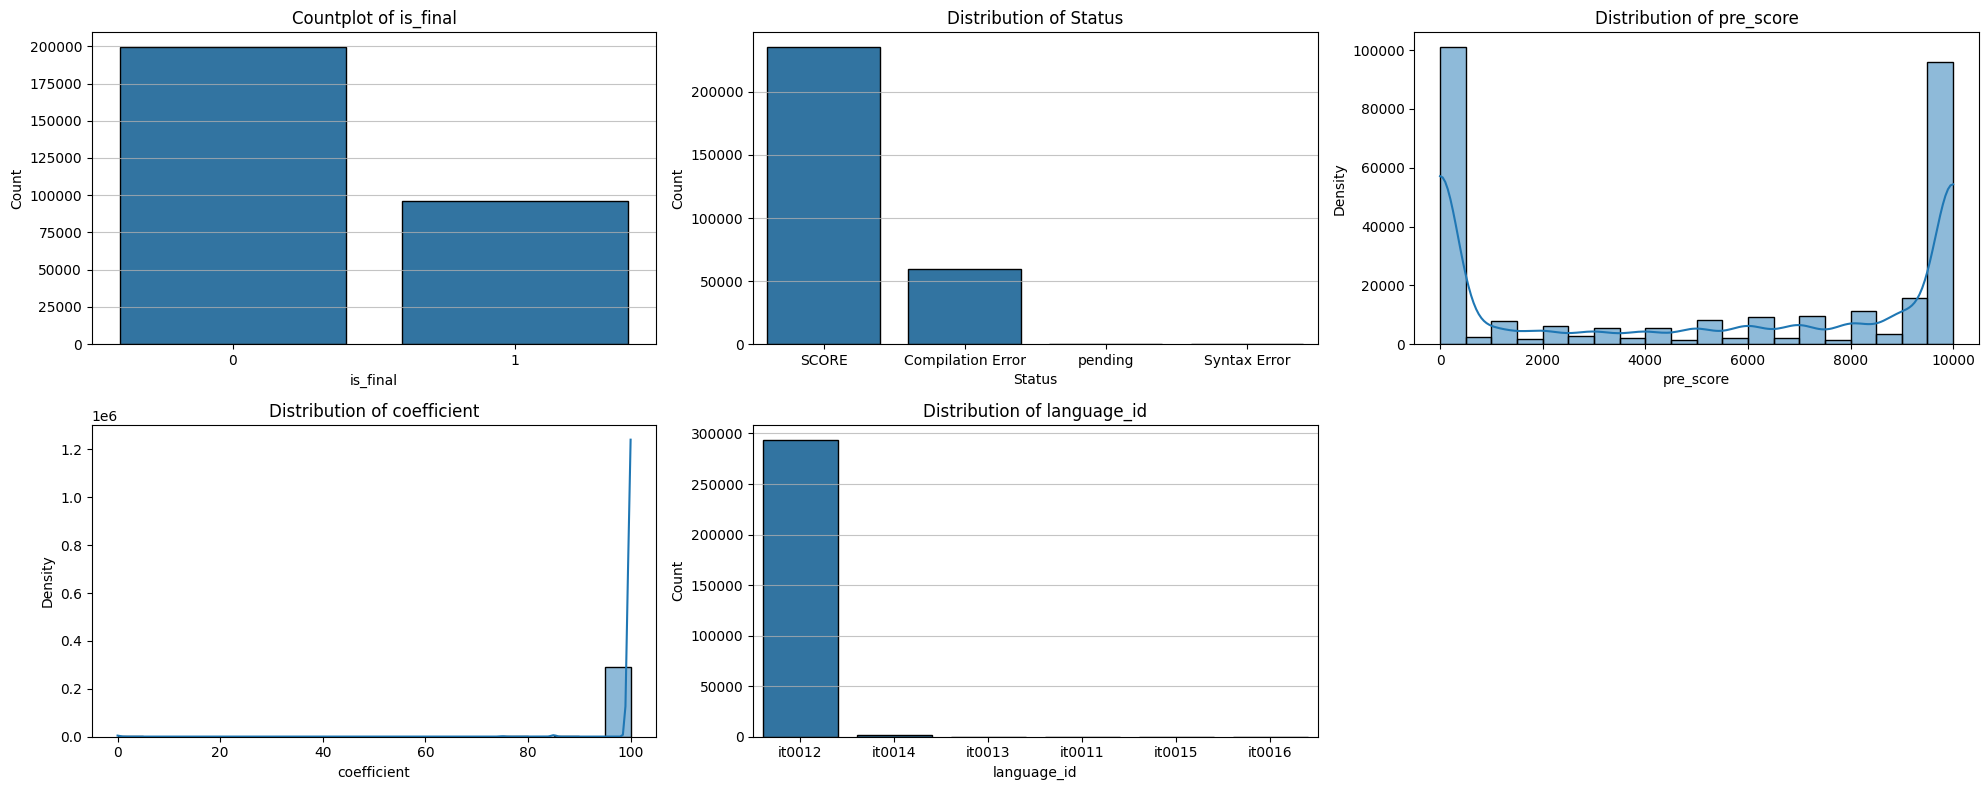

In [169]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(20, 8))

# Plot 1: Countplot of is_final
plt.subplot(2, 3, 1)  # 2 rows, 3 columns, position 1
sns.countplot(data=df, x='is_final', edgecolor='black')
plt.title('Countplot of is_final')
plt.xlabel('is_final')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.75)

# Plot 2: Countplot of status
plt.subplot(2, 3, 2)  # 2 rows, 3 columns, position 2
sns.countplot(data=df, x='status', edgecolor='black')
plt.title('Distribution of Status')
plt.xlabel('Status')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.75)

# Plot 3: Histogram of pre_score
plt.subplot(2, 3, 3)  # 2 rows, 3 columns, position 3
sns.histplot(df['pre_score'], kde=True, bins=20, edgecolor='black')
plt.title('Distribution of pre_score')
plt.xlabel('pre_score')
plt.ylabel('Density')

# Plot 4: Histogram of coefficient
plt.subplot(2, 3, 4)  # 2 rows, 3 columns, position 4
sns.histplot(df['coefficient'], kde=True, bins=20, edgecolor='black')
plt.title('Distribution of coefficient')
plt.xlabel('coefficient')
plt.ylabel('Density')

# Plot 5: Countplot of language_id
plt.subplot(2, 3, 5)  # 2 rows, 3 columns, position 5
sns.countplot(data=df, x='language_id', edgecolor='black')
plt.title('Distribution of language_id')
plt.xlabel('language_id')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.75)

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the figure
plt.show()


In [170]:
distinct_usernames = df['username'].nunique()

print(f"Number of distinct usernames: {distinct_usernames}")

Number of distinct usernames: 1489


# Data Engineer

In [171]:
'''score_df = df_tl[df_tl['username'].isin(df['username'])]'''

"score_df = df_tl[df_tl['username'].isin(df['username'])]"

In [172]:
score_df = pd.DataFrame({'username': df['username'].unique()})

# Create new feature

In [173]:
def create_try(score_df, df):
    try_count = df.groupby('username').size().reset_index(name='try')
    score_df = pd.merge(score_df, try_count, on='username', how='left')
    return score_df

In [174]:
score_df = create_try(score_df, df)

In [175]:
def create_improvement_in_score(score_df, df):
  df = df.sort_values(by=['username', 'created_at'])
  df['improved'] = df.groupby('username')['pre_score'].diff().apply(lambda x: 1 if x > 0 else 0)
  improvement_rate = df.groupby('username')['improved'].mean().reset_index(name='improvement_rate')
  score_df = pd.merge(score_df, improvement_rate, on='username', how='left')
  return score_df

In [176]:
score_df = create_improvement_in_score(score_df, df)

In [177]:
score_df.head()

,username,try,improvement_rate
0,ed9eaeb6a707f50154024b24d7efcb874a9795dd,139,0.273381
1,ba12c0a2cb367af0467e479c03507c71a805d291,319,0.300940
2,0bd2037bf68a97753e5e67ab55dac026a649f279,220,0.231818
3,b7298b0fe50443a623af9b56792b330c2d052845,247,0.263158
4,c60be70309789b39355dc612f36e37090ccad5dc,172,0.296512


In [178]:
data_with_year = ['2023-' + str(date) for date in df['created_at']]
df['created_at'] = data_with_year

df['created_at'] = pd.to_datetime(df['created_at'], format="%Y-%m-%d %H:%M:%S", errors='coerce')

In [179]:
def create_weekly_active_days(score_df, df):
  df['created_at'] = pd.to_datetime(df['created_at'], errors='coerce')
  df['week'] = df['created_at'].dt.isocalendar().week
  df['day'] = df['created_at'].dt.date
  weekly_active_days = (
    df.groupby(['username', 'week'])['day']
    .nunique()
    .reset_index(name='active_days_per_week')
  )
  avg_active_days = (
    weekly_active_days.groupby('username')['active_days_per_week']
    .mean()
    .reset_index(name='avg_active_days_per_week')
  )
  score_df = pd.merge(score_df, avg_active_days, on='username', how='left')
  score_df['avg_active_days_per_week'] = score_df['avg_active_days_per_week'].fillna(0)
  return score_df

In [180]:
score_df = create_weekly_active_days(score_df, df)

In [181]:
def create_solved(score_df, df):
    # Select relevant columns
    user_final_df = df[['username', 'is_final', 'pre_score']]

    # Filter rows where 'is_final' > 0 and 'pre_score' == 10000
    solved_df = user_final_df[(user_final_df['is_final'] > 0) & (user_final_df['pre_score'] == 10000)]

    # Group by 'username' and sum the 'is_final' column
    solved_df = solved_df.groupby('username').agg({'is_final': 'sum'})

    # Rename the 'is_final' column to 'solved'
    solved_df.rename(columns={'is_final':'solved'}, inplace=True)

    # Reset index to make 'username' a column again
    solved_df.reset_index(inplace=True)

    # Merge with the original score_df
    score_df = score_df.merge(solved_df, on='username', how='left')

    # Fill NaN values with 0.0
    score_df.fillna(0.0, inplace=True)

    return score_df

In [182]:
score_df = create_solved(score_df, df)

In [183]:
def create_total_score(score_df, df):
    # Select relevant columns from df
    user_score_df = df[['username', 'is_final', 'pre_score', 'coefficient']]

    # Apply the coefficient to pre_score
    user_score_df['adjusted_score'] = user_score_df['pre_score'] / 100 * user_score_df['coefficient']

    # Filter out rows where is_final is less than or equal to 0
    filtered_score_df = user_score_df[user_score_df['is_final'] > 0]

    # Group by username and sum the adjusted scores
    score = filtered_score_df.groupby('username')['adjusted_score'].sum().reset_index()

    # Rename the column as sum_score
    score.rename(columns={'adjusted_score': 'sum_score'}, inplace=True)

    # Merge the summed scores back into the original score_df
    score_df = pd.merge(score_df, score, on='username', how='left')

    score_df.fillna(0, inplace=True)

    return score_df

In [184]:
score_df = create_total_score(score_df, df)

<ipython-input-183-ee8520330462>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  user_score_df['adjusted_score'] = user_score_df['pre_score'] / 100 * user_score_df['coefficient']


In [185]:
def count_hard_question(score_df, df):
  solved_df = df[df['pre_score'] == 10000]
  solver_count_df = (
    solved_df.groupby('problem_id')['username']
    .nunique()
    .reset_index(name='solver_count')
  )
  hard_questions = solver_count_df[solver_count_df['solver_count'] < 400]['problem_id']
  hard_solved_df = solved_df[solved_df['problem_id'].isin(hard_questions)]
  hard_questions_count = (
    hard_solved_df.groupby('username')['problem_id']
    .nunique()
    .reset_index(name='hard_questions_solved')
  )
  score_df = pd.merge(score_df, hard_questions_count, on='username', how='left')
  score_df['hard_questions_solved'] = score_df['hard_questions_solved'].fillna(0).astype(int)
  return score_df

In [186]:
score_df = count_hard_question(score_df, df)

In [187]:
def create_num_submissions_per_problem(score_df, df):
  submissions_per_problem = df.groupby(['username', 'problem_id']).size().reset_index(name='submission_count')
  avg_submissions_per_problem = submissions_per_problem.groupby('username')['submission_count'].mean().reset_index(name='num_submissions_per_problem')
  score_df = pd.merge(score_df, avg_submissions_per_problem, on='username', how='left')
  score_df['num_submissions_per_problem'] = score_df['num_submissions_per_problem'].fillna(0)
  return score_df

In [188]:
score_df = create_num_submissions_per_problem(score_df, df)

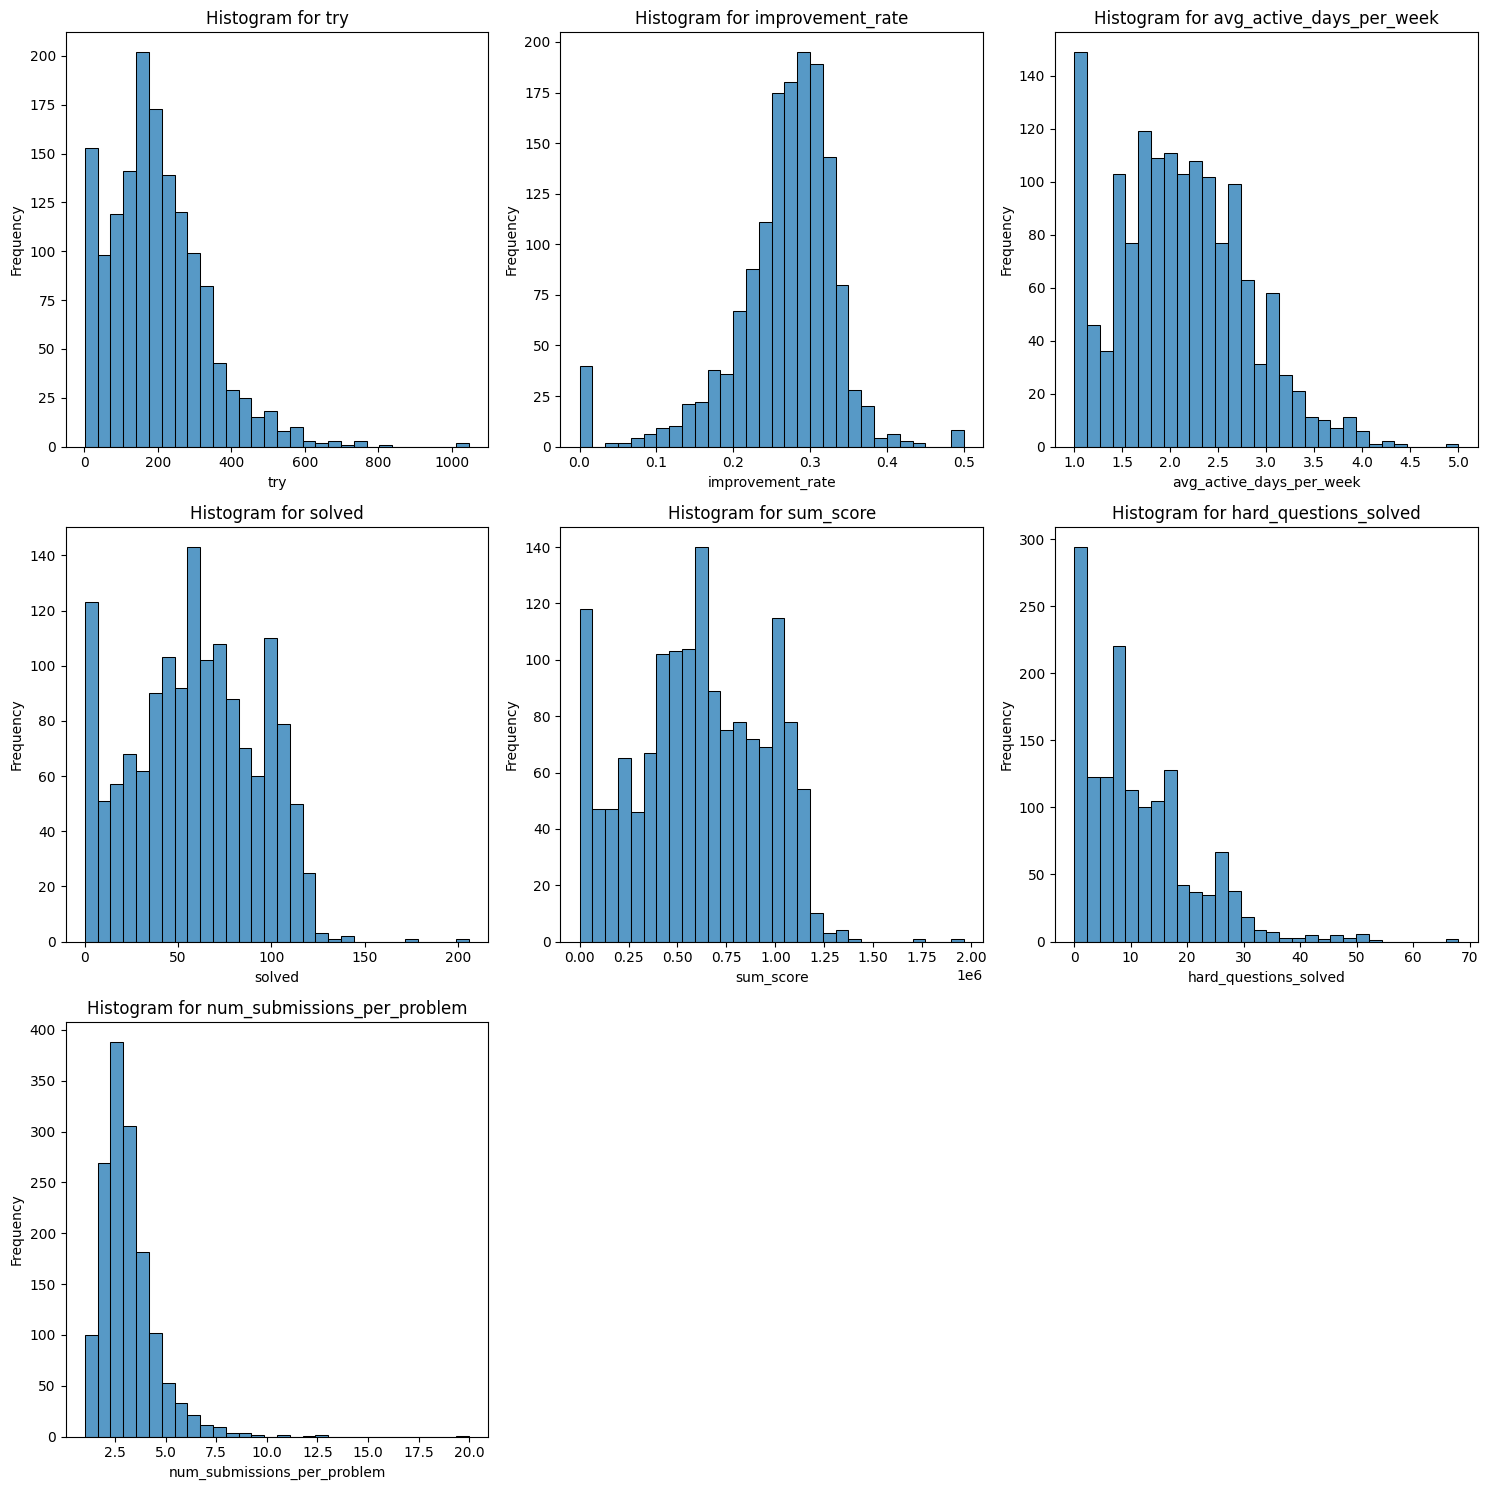

In [189]:
numeric_cols = score_df.select_dtypes(include='number').columns

# Determine the number of rows and columns for subplots
num_cols = len(numeric_cols)
rows = (num_cols + 2) // 3  # 3 plots per row
cols = 3

# Set the figure size
fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 5))

# Flatten axes for easy iteration
axes = axes.flatten()

# Iterate through numeric columns and corresponding axes
for i, col in enumerate(numeric_cols):
    sns.histplot(score_df[col], kde=False, bins=30, ax=axes[i])
    axes[i].set_title(f'Histogram for {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

# Remove unused subplots if any
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Adjust layout for clarity
plt.tight_layout()
plt.show()

Add target variable

In [190]:
def merge_with_target(score_df, target_df):
    # Merge score_df with tl_df based on 'username'
    merged_df = pd.merge(score_df, target_df, on='username', how='left')
    return merged_df

score_TBTL_df = merge_with_target(score_df, df_tl)
score_CK_df = merge_with_target(score_df, df_ck)
score_QT_df = merge_with_target(score_df, df_qt)
score_TH_df = merge_with_target(score_df, df_th)

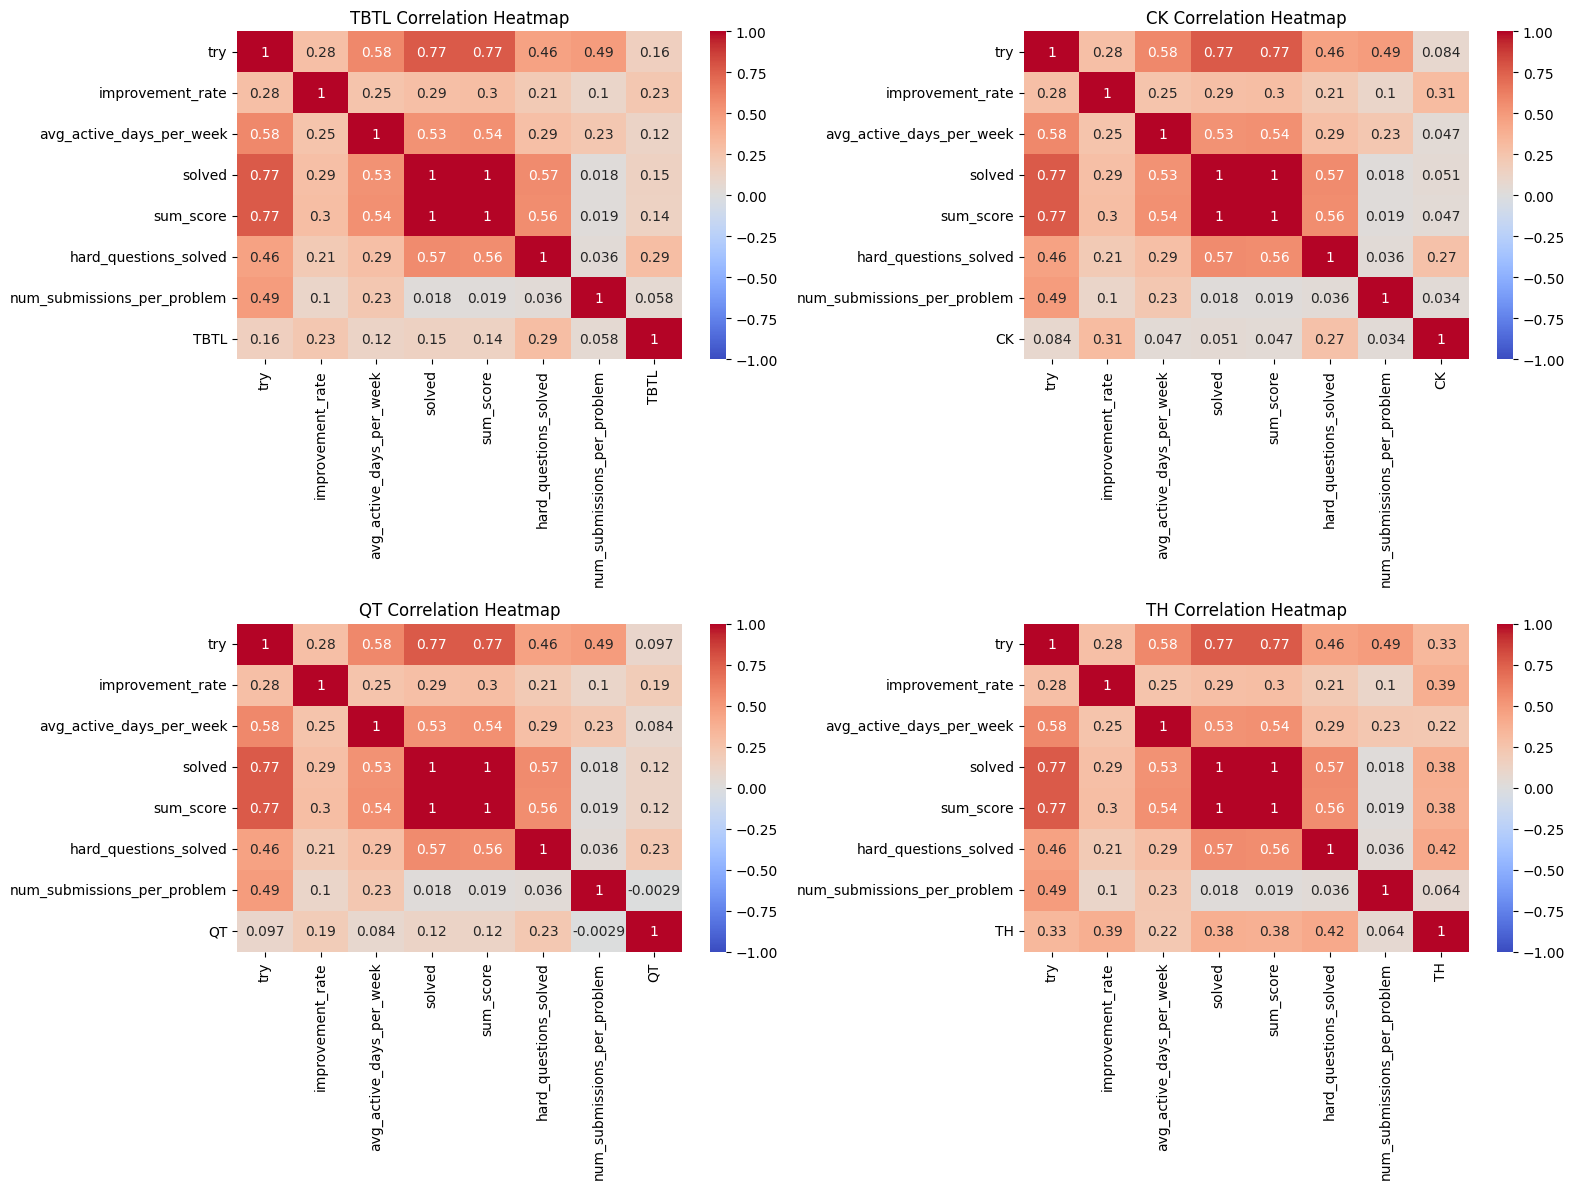

In [191]:
corr_tbtl_df = score_TBTL_df.select_dtypes(include='number').corr()
corr_ck_df = score_CK_df.select_dtypes(include='number').corr()
corr_qt_df = score_QT_df.select_dtypes(include='number').corr()
corr_th_df = score_TH_df.select_dtypes(include='number').corr()

# Store correlation matrices and titles in a list
correlation_matrices = [
    (corr_tbtl_df, "TBTL Correlation Heatmap"),
    (corr_ck_df, "CK Correlation Heatmap"),
    (corr_qt_df, "QT Correlation Heatmap"),
    (corr_th_df, "TH Correlation Heatmap"),
]

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))  # Adjust grid size to fit 4 plots
axes = axes.flatten()  # Flatten axes for easy iteration

# Plot each heatmap
for i, (corr_matrix, title) in enumerate(correlation_matrices):
    sns.heatmap(
        corr_matrix,
        annot=True,
        cmap="coolwarm",
        vmin=-1,
        vmax=1,
        ax=axes[i],
    )
    axes[i].set_title(title)

# Adjust layout for better spacing
plt.tight_layout()
plt.show()

# Train model

In [192]:
def create_predict_csv(predict_df, model, file_name, poly, train_feature_names):
    if 'username' not in predict_df.columns:
        raise ValueError("'username' column is missing in the prediction DataFrame.")

    usernames = predict_df['username']
    X_predict = predict_df.drop(columns=['username'])

    X_predict = poly.transform(X_predict)

    predict_data = xgb.DMatrix(X_predict, feature_names=train_feature_names)

    TBTL_predictions = model.predict(predict_data)

    results_df = pd.DataFrame({
        'username': usernames,
        'predict': TBTL_predictions
    })

    results_df['predict'] = results_df['predict'].round(2)

    results_df.to_csv(file_name, index=False, header=False)

Trung bình tích lũy


In [193]:
test_df = score_TBTL_df.copy()

In [194]:
def filter_nan_targets(df, target_col):
  return df[df[target_col].isna()]

In [195]:
def check_for_nan(df):
  nan_count = df.isna().sum()
  print(nan_count)

check_for_nan(test_df)

username                         0
try                              0
improvement_rate                 0
avg_active_days_per_week         0
solved                           0
sum_score                        0
hard_questions_solved            0
num_submissions_per_problem      0
TBTL                           690
dtype: int64


In [196]:
tbtl_result = filter_nan_targets(test_df, 'TBTL')

In [197]:
test_df = test_df.dropna(subset=['TBTL'])

In [198]:
test_df = test_df.drop(columns=['username'])

In [199]:
test_df.head()

,try,improvement_rate,avg_active_days_per_week,solved,sum_score,hard_questions_solved,num_submissions_per_problem,TBTL
2,220,0.231818,2.571429,47.0,490545.0,9,4.074074,8.17
5,3,0.333333,1.000000,0.0,3461.0,0,1.500000,6.75
8,117,0.153846,1.600000,10.0,106333.0,0,5.086957,7.70
9,455,0.340659,2.461538,110.0,1123224.0,24,3.888889,8.69
13,140,0.228571,2.333333,41.0,415846.0,0,3.684211,7.80


In [200]:
X = test_df.drop(columns=['TBTL'])
y = test_df['TBTL']

In [201]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

f0: 1
f1: try
f2: improvement_rate
f3: avg_active_days_per_week
f4: solved
f5: sum_score
f6: hard_questions_solved
f7: num_submissions_per_problem
f8: try^2
f9: try improvement_rate
f10: try avg_active_days_per_week
f11: try solved
f12: try sum_score
f13: try hard_questions_solved
f14: try num_submissions_per_problem
f15: improvement_rate^2
f16: improvement_rate avg_active_days_per_week
f17: improvement_rate solved
f18: improvement_rate sum_score
f19: improvement_rate hard_questions_solved
f20: improvement_rate num_submissions_per_problem
f21: avg_active_days_per_week^2
f22: avg_active_days_per_week solved
f23: avg_active_days_per_week sum_score
f24: avg_active_days_per_week hard_questions_solved
f25: avg_active_days_per_week num_submissions_per_problem
f26: solved^2
f27: solved sum_score
f28: solved hard_questions_solved
f29: solved num_submissions_per_problem
f30: sum_score^2
f31: sum_score hard_questions_solved
f32: sum_score num_submissions_per_problem
f33: hard_questions_solved^2


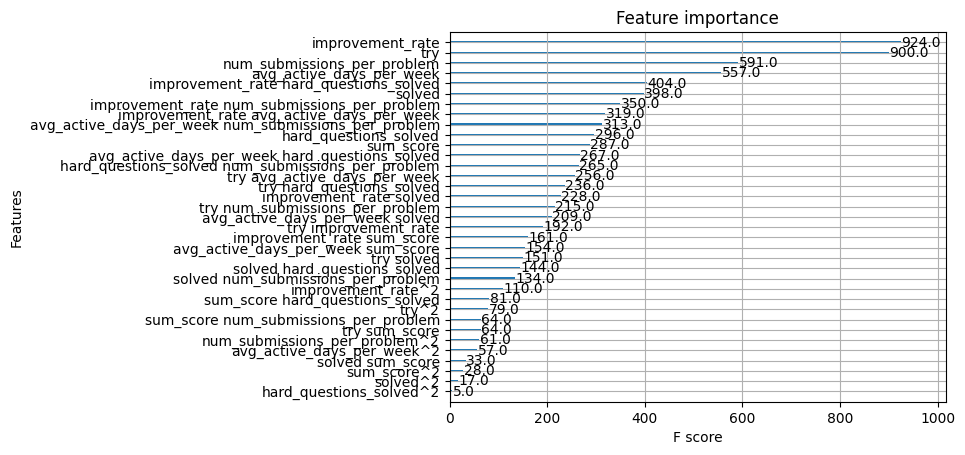

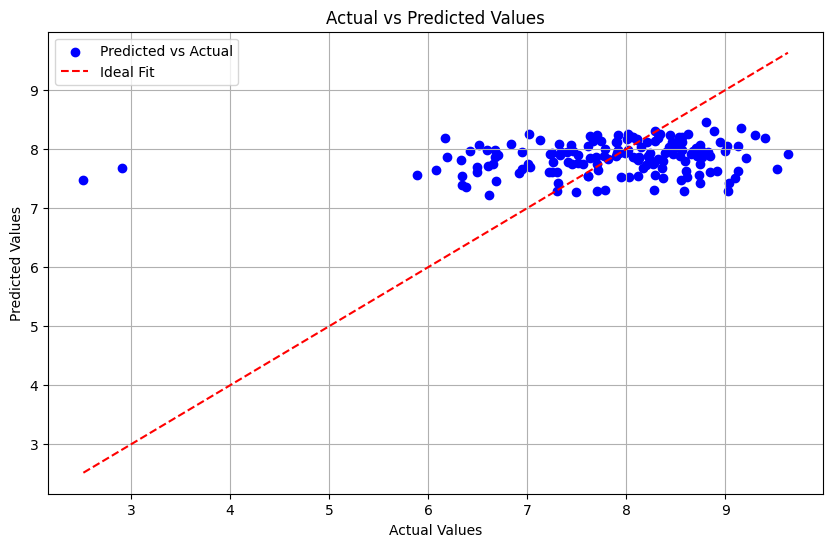

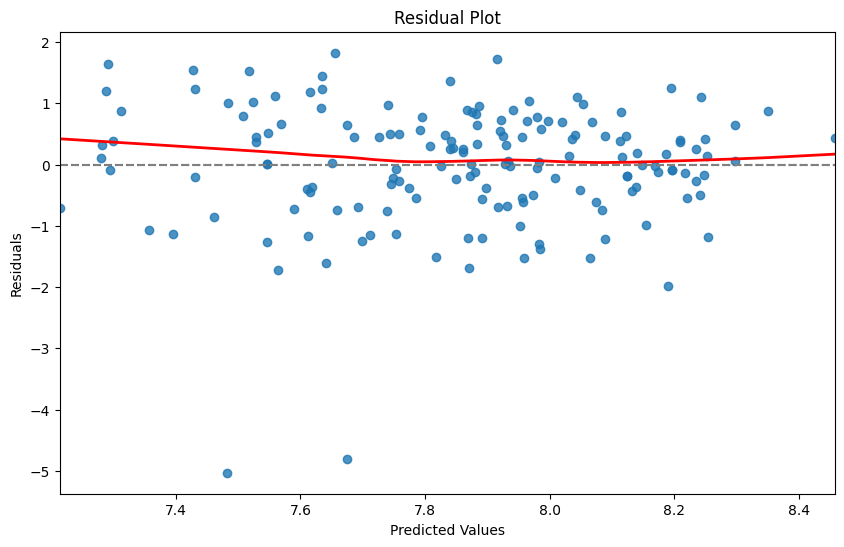

In [202]:
poly = PolynomialFeatures(degree=2)

X_train = poly.fit_transform(X_train)

X_test = poly.transform(X_test)

params = {
    'objective': 'reg:squarederror',
    'max_depth': 8,
    'gamma': 0.1,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'eta': 0.01,
    'eval_metric': 'rmse'
}


feature_names = poly.get_feature_names_out(input_features=X.columns).tolist()

# In tên các feature
for i, feature in enumerate(feature_names):
    print(f"f{i}: {feature}")


# Prepare the dataset and train the model
train_data = xgb.DMatrix(X_train, label=y_train, feature_names=feature_names)
test_data = xgb.DMatrix(X_test, label=y_test, feature_names=feature_names)

evals = [(train_data, 'train'), (test_data, 'eval')]
model = xgb.train(params, train_data, num_boost_round=100, evals=evals, early_stopping_rounds=50)

y_pred = model.predict(test_data)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"R^2 Score: {r2}")

importance = model.get_score(importance_type='weight')

# Ánh xạ tên feature
mapped_features = {f'f{i}': feature_names[i] for i in range(len(feature_names))}

# Thay thế f1, f2,... bằng tên đầy đủ
importance_mapped = {feature_names[int(k[1:])]: v for k, v in importance.items() if k[0] == 'f' and k[1:].isdigit()}
xgb.plot_importance(model)
plt.show()

residuals = y_test - y_pred

# Plot Actual vs. Predicted Values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color='blue', label='Predicted vs Actual')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', label='Ideal Fit')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Values')
plt.legend()
plt.grid(True)
plt.show()

# Step 5: Plot Residuals
plt.figure(figsize=(10, 6))
sns.residplot(x=y_pred, y=residuals, lowess=True, line_kws={'color': 'red', 'lw': 2})
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.axhline(0, linestyle='--', color='gray')
plt.show()

In [203]:
'''Xuất file dự đáon'''
tbtl_result = tbtl_result.drop(columns=['TBTL'])

train_feature_names = poly.get_feature_names_out(input_features=X.columns).tolist()

create_predict_csv(tbtl_result, model, 'result_tbtl.csv', poly, train_feature_names)


thực hành

In [204]:
test_df = score_TH_df.copy()

In [205]:
def filter_nan_targets(df, target_col):
  return df[df[target_col].isna()]

In [206]:
def check_for_nan(df):
  nan_count = df.isna().sum()
  print(nan_count)

check_for_nan(test_df)

username                         0
try                              0
improvement_rate                 0
avg_active_days_per_week         0
solved                           0
sum_score                        0
hard_questions_solved            0
num_submissions_per_problem      0
TH                             736
dtype: int64


In [207]:
th_result = filter_nan_targets(test_df, 'TH')

In [208]:
test_df = test_df.dropna(subset=['TH'])

In [209]:
test_df = test_df.drop(columns=['username'])

In [210]:
test_df.head()

,try,improvement_rate,avg_active_days_per_week,solved,sum_score,hard_questions_solved,num_submissions_per_problem,TH
2,220,0.231818,2.571429,47.0,490545.0,9,4.074074,4.5
5,3,0.333333,1.000000,0.0,3461.0,0,1.500000,3.5
8,117,0.153846,1.600000,10.0,106333.0,0,5.086957,1.0
9,455,0.340659,2.461538,110.0,1123224.0,24,3.888889,9.0
13,140,0.228571,2.333333,41.0,415846.0,0,3.684211,8.0


In [211]:
X = test_df.drop(columns=['TH'])
y = test_df['TH']

In [212]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

f0: 1
f1: try
f2: improvement_rate
f3: avg_active_days_per_week
f4: solved
f5: sum_score
f6: hard_questions_solved
f7: num_submissions_per_problem
f8: try^2
f9: try improvement_rate
f10: try avg_active_days_per_week
f11: try solved
f12: try sum_score
f13: try hard_questions_solved
f14: try num_submissions_per_problem
f15: improvement_rate^2
f16: improvement_rate avg_active_days_per_week
f17: improvement_rate solved
f18: improvement_rate sum_score
f19: improvement_rate hard_questions_solved
f20: improvement_rate num_submissions_per_problem
f21: avg_active_days_per_week^2
f22: avg_active_days_per_week solved
f23: avg_active_days_per_week sum_score
f24: avg_active_days_per_week hard_questions_solved
f25: avg_active_days_per_week num_submissions_per_problem
f26: solved^2
f27: solved sum_score
f28: solved hard_questions_solved
f29: solved num_submissions_per_problem
f30: sum_score^2
f31: sum_score hard_questions_solved
f32: sum_score num_submissions_per_problem
f33: hard_questions_solved^2


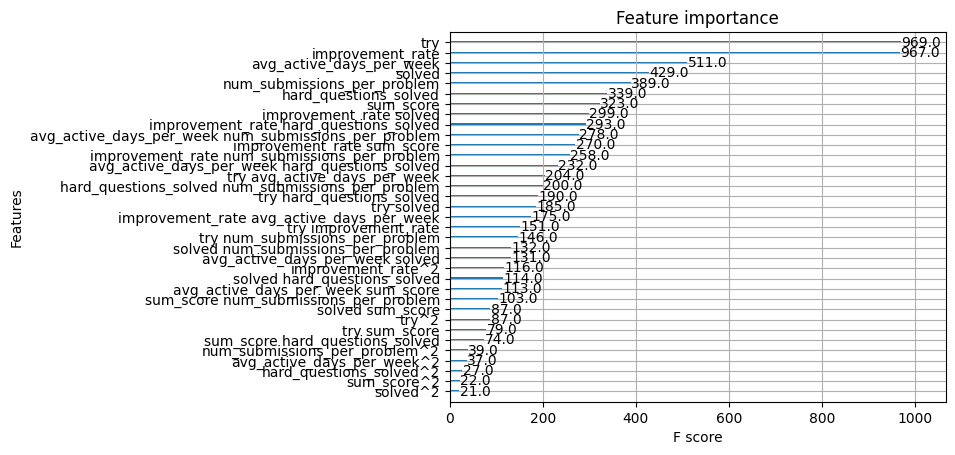

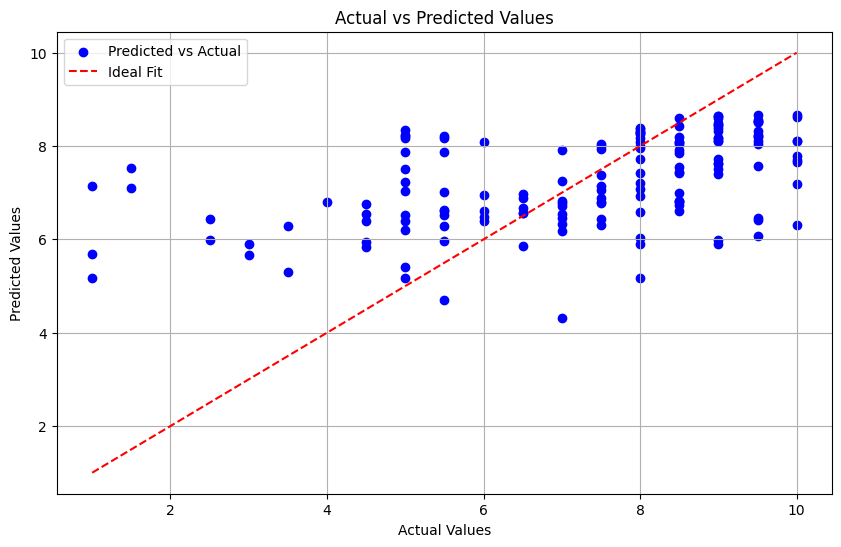

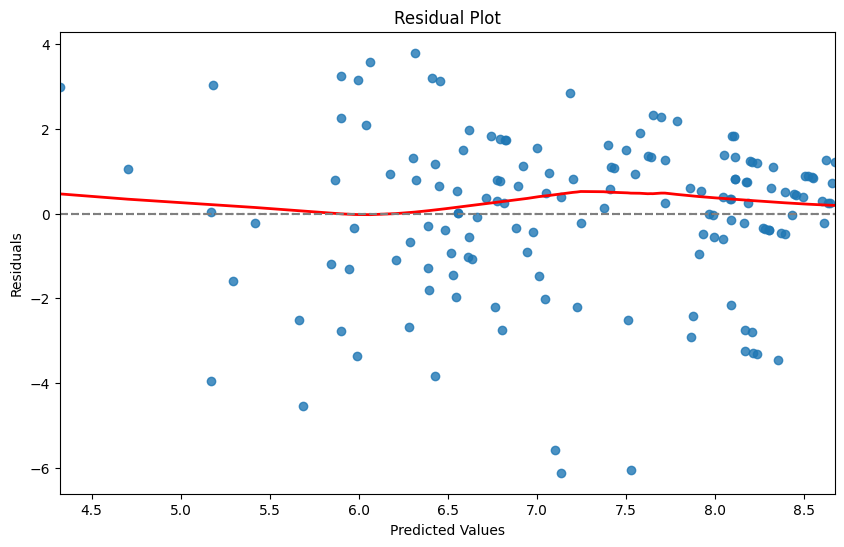

In [213]:
poly = PolynomialFeatures(degree=2)

X_train = poly.fit_transform(X_train)

X_test = poly.transform(X_test)

params = {
    'objective': 'reg:squarederror',
    'max_depth': 8,
    'gamma': 0.1,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'eta': 0.01,
    'eval_metric': 'rmse'
}


feature_names = poly.get_feature_names_out(input_features=X.columns).tolist()

# In tên các feature
for i, feature in enumerate(feature_names):
    print(f"f{i}: {feature}")


# Prepare the dataset and train the model
train_data = xgb.DMatrix(X_train, label=y_train, feature_names=feature_names)
test_data = xgb.DMatrix(X_test, label=y_test, feature_names=feature_names)

evals = [(train_data, 'train'), (test_data, 'eval')]
model = xgb.train(params, train_data, num_boost_round=100, evals=evals, early_stopping_rounds=50)

y_pred = model.predict(test_data)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"R^2 Score: {r2}")

importance = model.get_score(importance_type='weight')

# Ánh xạ tên feature
mapped_features = {f'f{i}': feature_names[i] for i in range(len(feature_names))}

# Thay thế f1, f2,... bằng tên đầy đủ
importance_mapped = {feature_names[int(k[1:])]: v for k, v in importance.items() if k[0] == 'f' and k[1:].isdigit()}
xgb.plot_importance(model)
plt.show()

residuals = y_test - y_pred

# Plot Actual vs. Predicted Values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color='blue', label='Predicted vs Actual')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', label='Ideal Fit')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Values')
plt.legend()
plt.grid(True)
plt.show()

# Step 5: Plot Residuals
plt.figure(figsize=(10, 6))
sns.residplot(x=y_pred, y=residuals, lowess=True, line_kws={'color': 'red', 'lw': 2})
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.axhline(0, linestyle='--', color='gray')
plt.show()

In [214]:
'''Xuất file dự đáon'''
th_result = th_result.drop(columns=['TH'])

train_feature_names = poly.get_feature_names_out(input_features=X.columns).tolist()

create_predict_csv(th_result, model, 'result_th.csv', poly, train_feature_names)

Quá trình

In [215]:
test_df = score_QT_df.copy()

In [216]:
def filter_nan_targets(df, target_col):
  return df[df[target_col].isna()]

In [217]:
def check_for_nan(df):
  nan_count = df.isna().sum()
  print(nan_count)

check_for_nan(test_df)

username                         0
try                              0
improvement_rate                 0
avg_active_days_per_week         0
solved                           0
sum_score                        0
hard_questions_solved            0
num_submissions_per_problem      0
QT                             735
dtype: int64


In [218]:
qt_result = filter_nan_targets(test_df, 'QT')

In [219]:
test_df = test_df.dropna(subset=['QT'])

In [220]:
test_df = test_df.drop(columns=['username'])

In [221]:
X = test_df.drop(columns=['QT'])
y = test_df['QT']

In [222]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

f0: 1
f1: try
f2: improvement_rate
f3: avg_active_days_per_week
f4: solved
f5: sum_score
f6: hard_questions_solved
f7: num_submissions_per_problem
f8: try^2
f9: try improvement_rate
f10: try avg_active_days_per_week
f11: try solved
f12: try sum_score
f13: try hard_questions_solved
f14: try num_submissions_per_problem
f15: improvement_rate^2
f16: improvement_rate avg_active_days_per_week
f17: improvement_rate solved
f18: improvement_rate sum_score
f19: improvement_rate hard_questions_solved
f20: improvement_rate num_submissions_per_problem
f21: avg_active_days_per_week^2
f22: avg_active_days_per_week solved
f23: avg_active_days_per_week sum_score
f24: avg_active_days_per_week hard_questions_solved
f25: avg_active_days_per_week num_submissions_per_problem
f26: solved^2
f27: solved sum_score
f28: solved hard_questions_solved
f29: solved num_submissions_per_problem
f30: sum_score^2
f31: sum_score hard_questions_solved
f32: sum_score num_submissions_per_problem
f33: hard_questions_solved^2


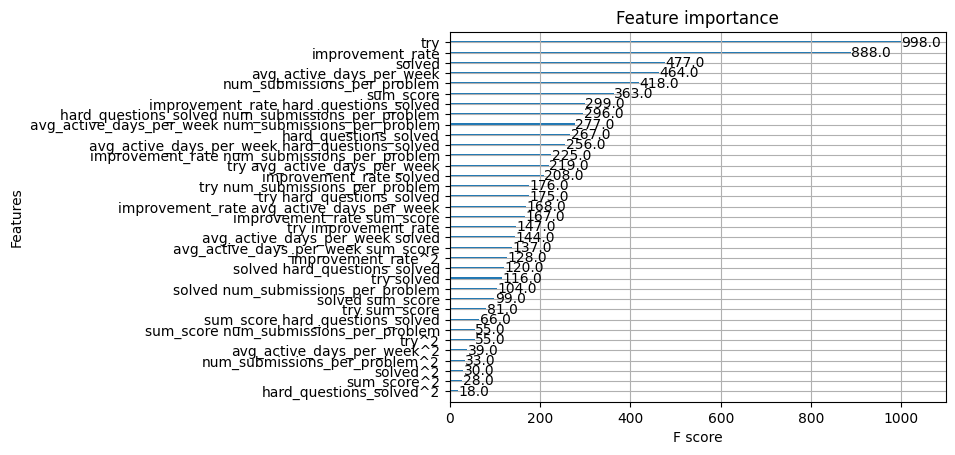

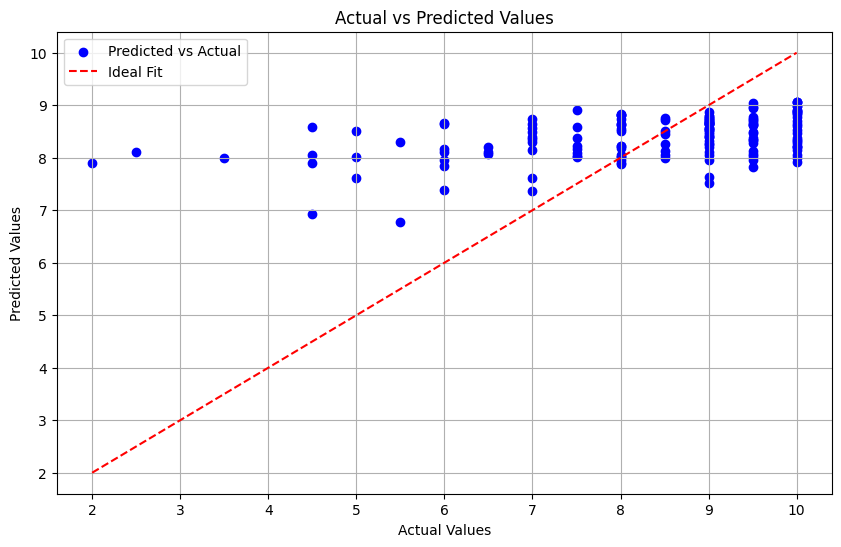

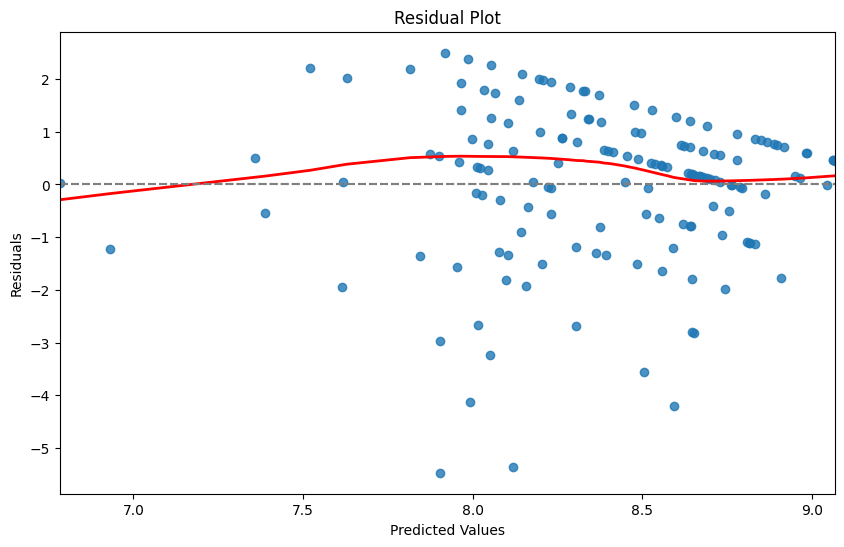

In [223]:
poly = PolynomialFeatures(degree=2)

X_train = poly.fit_transform(X_train)

X_test = poly.transform(X_test)

params = {
    'objective': 'reg:squarederror',
    'max_depth': 8,
    'gamma': 0.1,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'eta': 0.01,
    'eval_metric': 'rmse'
}


feature_names = poly.get_feature_names_out(input_features=X.columns).tolist()

# In tên các feature
for i, feature in enumerate(feature_names):
    print(f"f{i}: {feature}")


# Prepare the dataset and train the model
train_data = xgb.DMatrix(X_train, label=y_train, feature_names=feature_names)
test_data = xgb.DMatrix(X_test, label=y_test, feature_names=feature_names)

evals = [(train_data, 'train'), (test_data, 'eval')]
model = xgb.train(params, train_data, num_boost_round=100, evals=evals, early_stopping_rounds=50)

y_pred = model.predict(test_data)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"R^2 Score: {r2}")

importance = model.get_score(importance_type='weight')

# Ánh xạ tên feature
mapped_features = {f'f{i}': feature_names[i] for i in range(len(feature_names))}

# Thay thế f1, f2,... bằng tên đầy đủ
importance_mapped = {feature_names[int(k[1:])]: v for k, v in importance.items() if k[0] == 'f' and k[1:].isdigit()}
xgb.plot_importance(model)
plt.show()

residuals = y_test - y_pred

# Plot Actual vs. Predicted Values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color='blue', label='Predicted vs Actual')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', label='Ideal Fit')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Values')
plt.legend()
plt.grid(True)
plt.show()

# Step 5: Plot Residuals
plt.figure(figsize=(10, 6))
sns.residplot(x=y_pred, y=residuals, lowess=True, line_kws={'color': 'red', 'lw': 2})
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.axhline(0, linestyle='--', color='gray')
plt.show()

In [224]:
'''Xuất file dự đáon'''
qt_result = qt_result.drop(columns=['QT'])

train_feature_names = poly.get_feature_names_out(input_features=X.columns).tolist()

create_predict_csv(qt_result, model, 'result_qt.csv', poly, train_feature_names)

Cuối kỳ

In [225]:
test_df = score_CK_df.copy()

In [226]:
def filter_nan_targets(df, target_col):
  return df[df[target_col].isna()]

In [227]:
def check_for_nan(df):
  nan_count = df.isna().sum()
  print(nan_count)

check_for_nan(test_df)

username                         0
try                              0
improvement_rate                 0
avg_active_days_per_week         0
solved                           0
sum_score                        0
hard_questions_solved            0
num_submissions_per_problem      0
CK                             734
dtype: int64


In [228]:
ck_result = filter_nan_targets(test_df, 'CK')

In [229]:
test_df = test_df.dropna(subset=['CK'])

In [230]:
test_df = test_df.drop(columns=['username'])

In [231]:
X = test_df.drop(columns=['CK'])
y = test_df['CK']

In [232]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

f0: 1
f1: try
f2: improvement_rate
f3: avg_active_days_per_week
f4: solved
f5: sum_score
f6: hard_questions_solved
f7: num_submissions_per_problem
f8: try^2
f9: try improvement_rate
f10: try avg_active_days_per_week
f11: try solved
f12: try sum_score
f13: try hard_questions_solved
f14: try num_submissions_per_problem
f15: improvement_rate^2
f16: improvement_rate avg_active_days_per_week
f17: improvement_rate solved
f18: improvement_rate sum_score
f19: improvement_rate hard_questions_solved
f20: improvement_rate num_submissions_per_problem
f21: avg_active_days_per_week^2
f22: avg_active_days_per_week solved
f23: avg_active_days_per_week sum_score
f24: avg_active_days_per_week hard_questions_solved
f25: avg_active_days_per_week num_submissions_per_problem
f26: solved^2
f27: solved sum_score
f28: solved hard_questions_solved
f29: solved num_submissions_per_problem
f30: sum_score^2
f31: sum_score hard_questions_solved
f32: sum_score num_submissions_per_problem
f33: hard_questions_solved^2


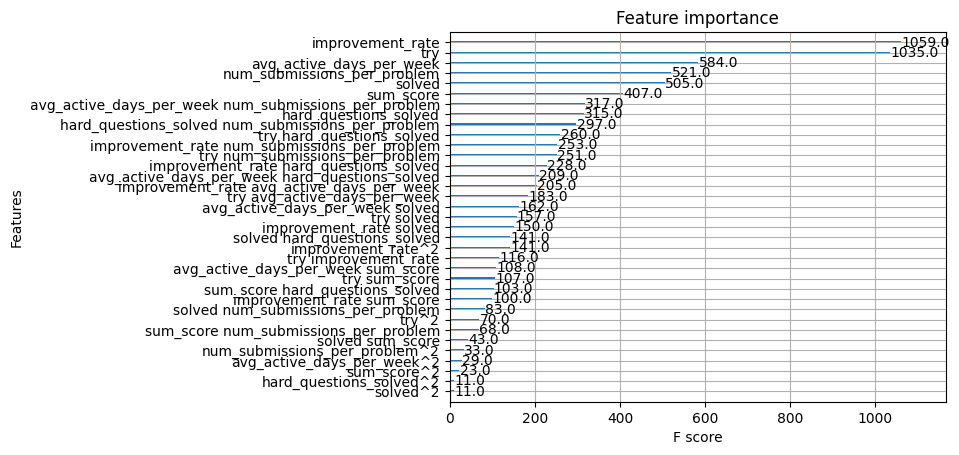

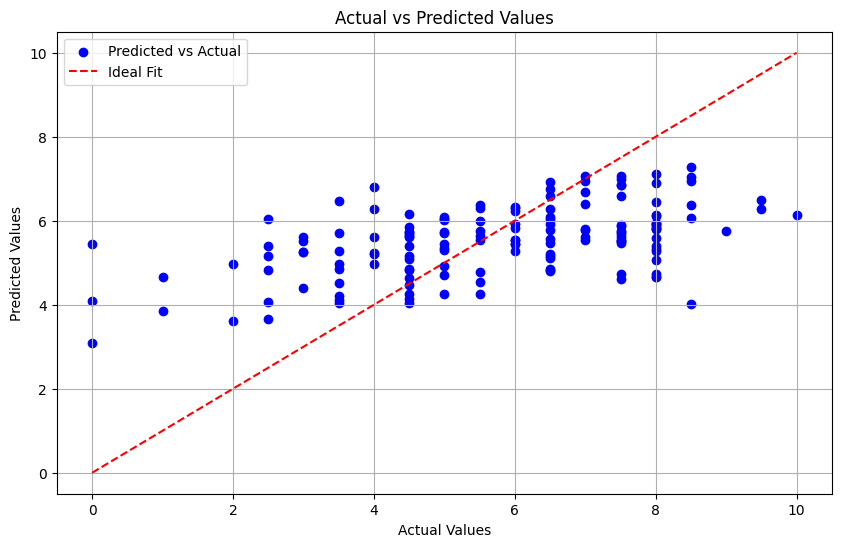

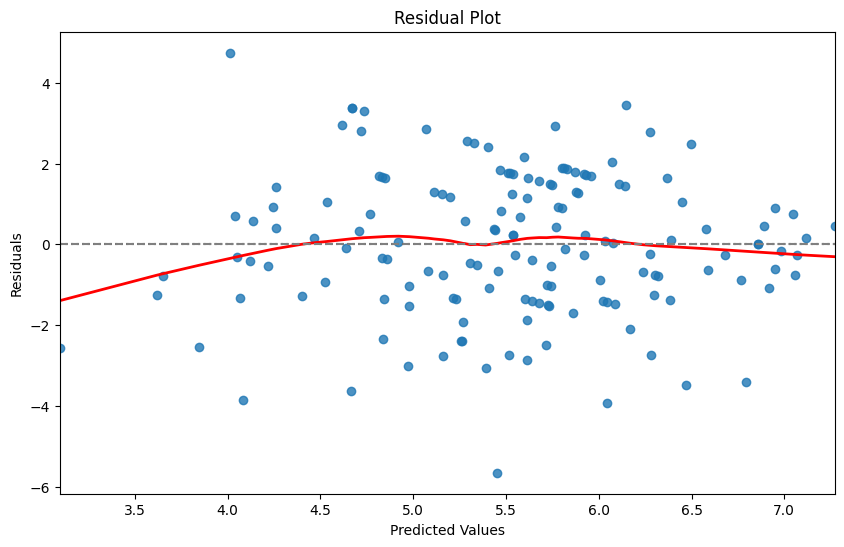

In [233]:
poly = PolynomialFeatures(degree=2)

X_train = poly.fit_transform(X_train)

X_test = poly.transform(X_test)

params = {
    'objective': 'reg:squarederror',
    'max_depth': 8,
    'gamma': 0.1,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'eta': 0.01,
    'eval_metric': 'rmse'
}


feature_names = poly.get_feature_names_out(input_features=X.columns).tolist()

# In tên các feature
for i, feature in enumerate(feature_names):
    print(f"f{i}: {feature}")


# Prepare the dataset and train the model
train_data = xgb.DMatrix(X_train, label=y_train, feature_names=feature_names)
test_data = xgb.DMatrix(X_test, label=y_test, feature_names=feature_names)

evals = [(train_data, 'train'), (test_data, 'eval')]
model = xgb.train(params, train_data, num_boost_round=100, evals=evals, early_stopping_rounds=50)

y_pred = model.predict(test_data)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"R^2 Score: {r2}")

importance = model.get_score(importance_type='weight')

# Ánh xạ tên feature
mapped_features = {f'f{i}': feature_names[i] for i in range(len(feature_names))}

# Thay thế f1, f2,... bằng tên đầy đủ
importance_mapped = {feature_names[int(k[1:])]: v for k, v in importance.items() if k[0] == 'f' and k[1:].isdigit()}
xgb.plot_importance(model)
plt.show()

residuals = y_test - y_pred

# Plot Actual vs. Predicted Values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color='blue', label='Predicted vs Actual')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', label='Ideal Fit')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Values')
plt.legend()
plt.grid(True)
plt.show()

# Step 5: Plot Residuals
plt.figure(figsize=(10, 6))
sns.residplot(x=y_pred, y=residuals, lowess=True, line_kws={'color': 'red', 'lw': 2})
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.axhline(0, linestyle='--', color='gray')
plt.show()

# Create CSV

In [234]:
ck_result.head()

,username,try,improvement_rate,avg_active_days_per_week,solved,sum_score,hard_questions_solved,num_submissions_per_problem,CK
0,ed9eaeb6a707f50154024b24d7efcb874a9795dd,139,0.273381,2.666667,56.0,568500.0,9,2.396552,NaN
1,ba12c0a2cb367af0467e479c03507c71a805d291,319,0.300940,3.000000,117.0,1170000.0,29,2.848214,NaN
3,b7298b0fe50443a623af9b56792b330c2d052845,247,0.263158,2.636364,108.0,1090307.0,25,2.245455,NaN
4,c60be70309789b39355dc612f36e37090ccad5dc,172,0.296512,1.916667,76.0,807000.0,2,2.072289,NaN
6,a22a58c5be8aa2c2700619e37f2b7a6e4efa7e6b,288,0.267361,3.454545,98.0,1004222.0,17,2.796117,NaN


In [235]:
ck_result = ck_result.drop(columns=['CK'])

train_feature_names = poly.get_feature_names_out(input_features=X.columns).tolist()

create_predict_csv(ck_result, model, 'result_ck.csv', poly, train_feature_names)
